**Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [6]:
df=pd.read_csv('/content/22070521127_ML_raw.csv')

**Know about dataset**

In [7]:
df.head()

,id,date,state_name,state_code,district_name,district_code,station_name,latitude,longitude,basin,sub_basin,source,currentlevel,level_diff
0,0,04-11-2013,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.10,-1.03
1,1,14-05-2014,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.60,2.50
2,2,04-11-2014,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.35,-2.25
3,3,14-05-2015,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.52,2.17
4,4,04-11-2015,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.69,-1.83


In [8]:
df.describe()

,id,state_code,district_code,latitude,longitude,currentlevel,level_diff
count,125115.000000,125115.000000,125115.000000,125115.000000,125115.000000,125114.000000,125114.000000
mean,62557.000000,22.399912,394.232586,19.504227,84.217318,7.743548,-0.011837
std,36117.733802,7.538576,136.390602,5.448468,3.762535,9.847522,7.768834
min,0.000000,10.000000,188.000000,9.641390,76.758330,0.000000,-107.750000
25%,31278.500000,19.000000,312.000000,11.722220,79.602780,2.400000,-1.330000
50%,62557.000000,21.000000,353.000000,21.196670,85.112220,4.400000,0.270000
75%,93835.500000,33.000000,570.000000,23.683330,87.339720,7.630000,1.480000
max,125114.000000,35.000000,704.000000,27.429170,93.060000,150.400000,104.020000


In [9]:
df.shape

(125115, 14)

**Data cleaning and preprocessing**

In [10]:
#Check for null values in numerical columns
df.isnull().sum()

,0
id,0
date,0
state_name,0
state_code,0
district_name,0
district_code,0
station_name,0
latitude,0
longitude,0
basin,0


In [11]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
#Data-types of each column
df.dtypes

,0
id,int64
date,object
state_name,object
state_code,int64
district_name,object
district_code,int64
station_name,object
latitude,float64
longitude,float64
basin,object


In [13]:
# Convert date
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

# Fix lat/long issues if any
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
df.head()

,id,date,state_name,state_code,district_name,district_code,station_name,latitude,longitude,basin,sub_basin,source,currentlevel,level_diff
0,0,2013-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.10,-1.03
1,1,2014-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.60,2.50
2,2,2014-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.35,-2.25
3,3,2015-05-14,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,2.52,2.17
4,4,2015-11-04,Andaman And Nicobar Islands,35,North And Middle Andaman,632,Laxmipur,13.28556,93.00306,Drainage Area Of Andaman And Nicobar Islands B...,Drainage Area Of Andaman And Nicobar Islands,CGWB,0.69,-1.83


**Univariate Analysis**

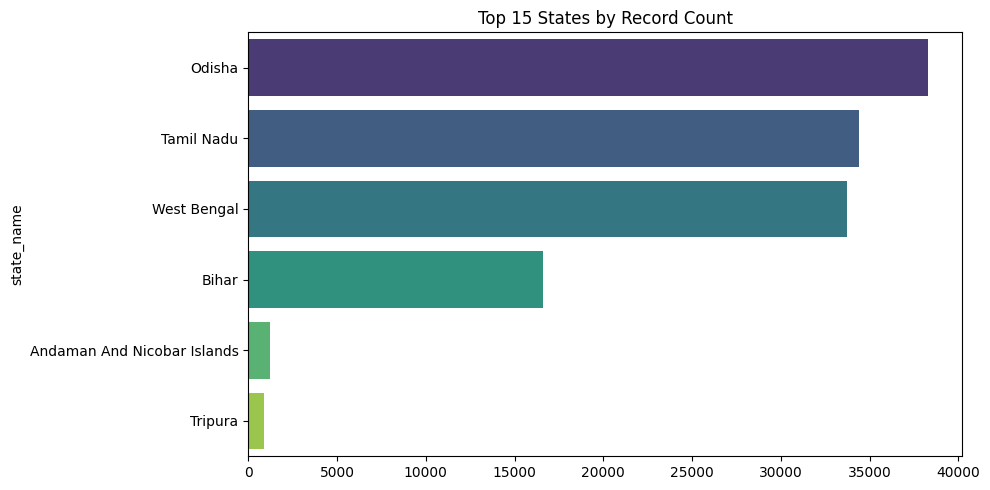

In [14]:
# UNIVARIATE ANALYSIS — Categorical
top_states = df['state_name'].value_counts().nlargest(15)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette="viridis", legend=False)
plt.title("Top 15 States by Record Count")
plt.tight_layout()
plt.show()

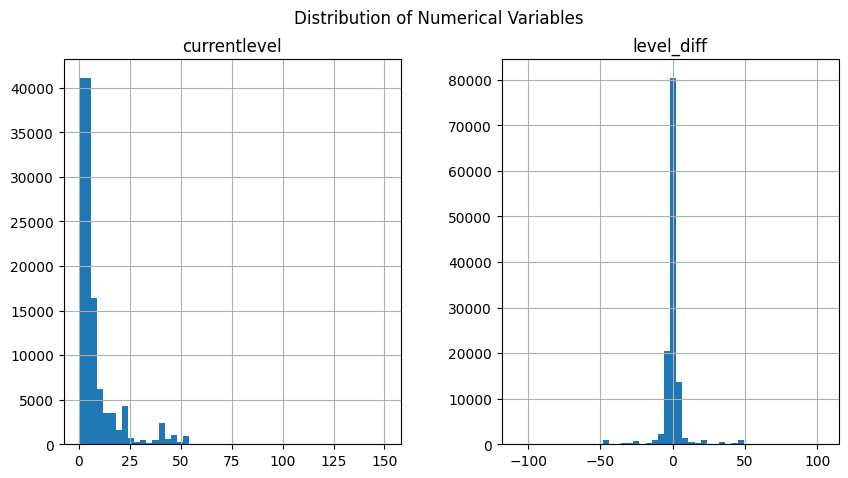

In [15]:
# Numerical variable analysis
numeric_cols = ['currentlevel', 'level_diff']
df[numeric_cols].hist(bins=50, figsize=(10,5))
plt.suptitle("Distribution of Numerical Variables")
plt.show()

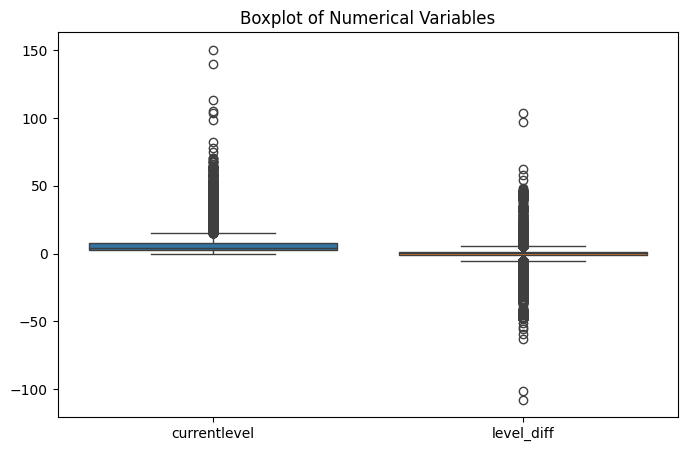

In [16]:
# Boxplots for outlier detection
plt.figure(figsize=(8,5))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numerical Variables")
plt.show()

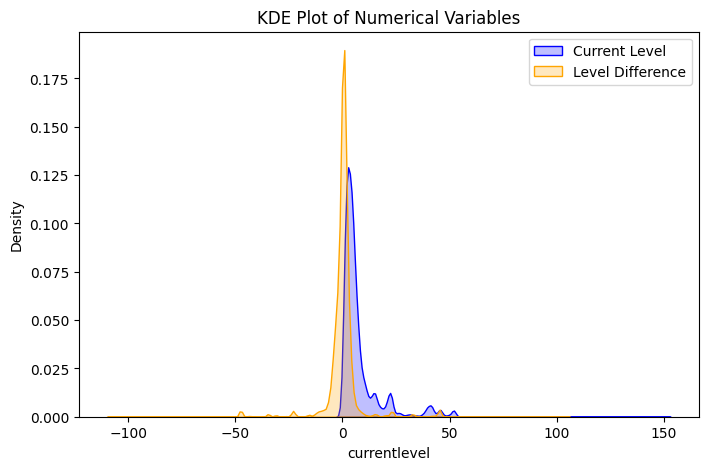

In [17]:
# KDE plots for smooth distribution view
plt.figure(figsize=(8,5))
sns.kdeplot(df['currentlevel'], fill=True, color='blue', label='Current Level')
sns.kdeplot(df['level_diff'], fill=True, color='orange', label='Level Difference')
plt.title("KDE Plot of Numerical Variables")
plt.legend()
plt.show()

**Bivariate Analysis**

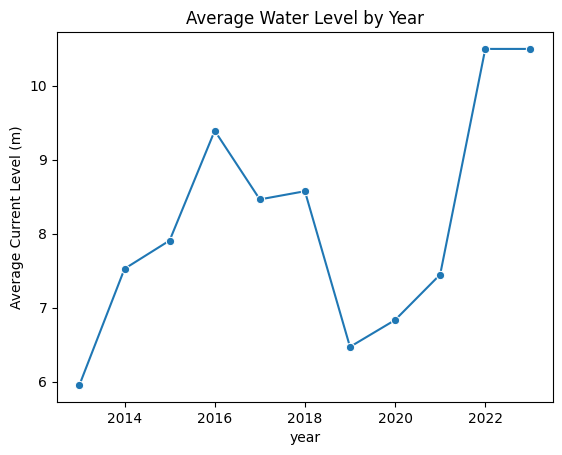

In [18]:
# Water level trend by Year
df['year'] = df['date'].dt.year
yearly_trend = df.groupby("year")["currentlevel"].mean().reset_index()
sns.lineplot(data=yearly_trend, x="year", y="currentlevel", marker="o")
plt.title("Average Water Level by Year")
plt.ylabel("Average Current Level (m)")
plt.show()

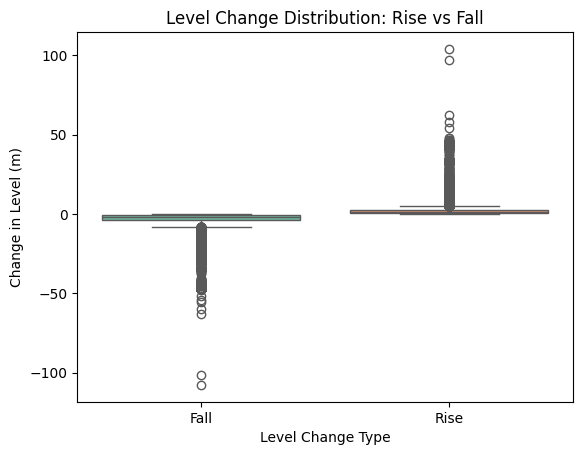

In [19]:
# Compare actual vs estimated (rise/fall levels)
df['level_change_flag'] = df['level_diff'].apply(lambda x: 'Rise' if x > 0 else 'Fall')

sns.boxplot(data=df, x='level_change_flag', y='level_diff', hue='level_change_flag', palette="Set2", legend=False)
plt.title("Level Change Distribution: Rise vs Fall")
plt.xlabel("Level Change Type")
plt.ylabel("Change in Level (m)")
plt.show()

In [20]:
# Drop the original 'date' column
df = df.drop(columns=['date'])

# Reorder columns
columns_order = [
    'id', 'year', 'state_name', 'district_name', 'station_name',
    'latitude', 'longitude', 'currentlevel', 'level_diff', 'level_change_flag'
]

# Apply new column order
df = df[columns_order]


In [21]:
# Outlier detection of current water level
Q1 = df['currentlevel'].quantile(0.25)
Q3 = df['currentlevel'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['currentlevel'] < Q1 - 1.5 * IQR) | (df['currentlevel'] > Q3 + 1.5 * IQR)]
print(f"Outliers in 'currentlevel': {len(outliers)}")

Outliers in 'currentlevel': 14883


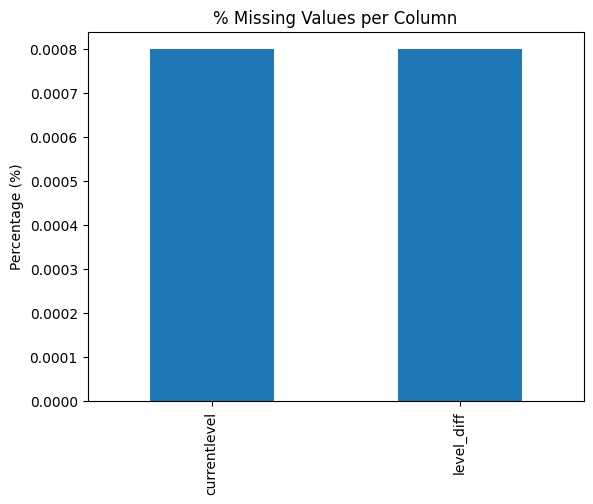

In [22]:
# Missing values checking
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]
if not missing_percent.empty:
    missing_percent.plot(kind='bar', title="% Missing Values per Column")
    plt.ylabel("Percentage (%)")
    plt.show()
else:
    print("No missing values.")

**Download newly processed dataset:**

In [23]:
#Download newly made dataset
from google.colab import files

# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_ML_Dataset.csv', index=False)

# Provide a download link
files.download('cleaned_ML_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>